# **Identifying Appropriate Clustering Algorithms**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# **PART 1**

In [ ]:
df1 = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-01.csv")
df1.head()

,V1,V2,V3,V4,V5
0,54.967142,118.523551,191.980663,231.134443,216.241086
1,48.617357,138.188333,177.739011,177.952571,242.774067
2,56.476885,72.028649,151.788911,167.272045,210.379004
3,65.230299,111.259385,130.591897,199.865022,234.601923
4,47.658466,86.987149,170.946699,193.192615,155.319267


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df1)

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled)

In [ ]:
range_n = range(2, 8)  # Test 2 to 7 clusters
silhouette_results = {"KMeans": [], "HC": [], "GMM": []}

In [ ]:
for k in range_n:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["KMeans"].append(score)

In [ ]:
for k in range_n:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["HC"].append(score)

In [ ]:
for k in range_n:
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["GMM"].append(score)

In [ ]:
results_df1 = pd.DataFrame(silhouette_results, index=range_n)
print("Silhouette Scores for Each Model:\n")
results_df1

Silhouette Scores for Each Model:



,KMeans,HC,GMM
2,0.310540,0.276970,0.310079
3,0.323875,0.272583,0.316851
4,0.313582,0.281305,0.316209
5,0.310269,0.294865,0.301826
6,0.357782,0.301191,0.352289
7,0.340461,0.271318,0.333000


# **1.**

In [ ]:
best_model = results_df1.max().idxmax()
best_k = results_df1[best_model].idxmax()
best_score = results_df1[best_model].max()

print("Best clustering model for dataset 'cluster-01.csv':", best_model)

Best clustering model for dataset 'cluster-01.csv': KMeans


# **2.**

In [ ]:
print("Best Silhouette Score:", round(best_score, 4))
print("Best Number of Clusters:", best_k)

Best Silhouette Score: 0.3578
Best Number of Clusters: 6


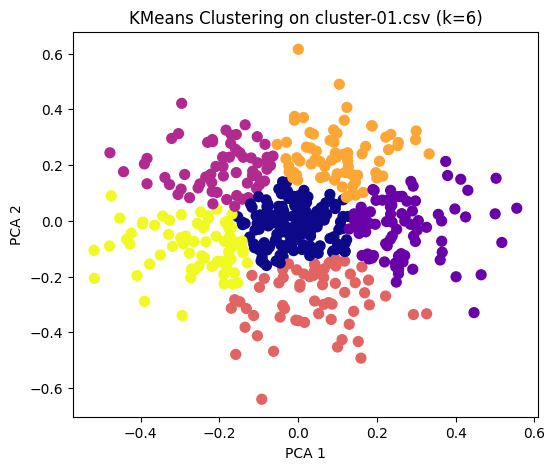

In [ ]:
kmeans_model_df1 = KMeans(n_clusters=6, random_state=42)
labels_df1 = kmeans_model_df1.fit_predict(pca_data)

plt.figure(figsize=(6, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_df1, cmap='plasma', s=50)
plt.title("KMeans Clustering on cluster-01.csv (k=6)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [ ]:
df2 = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-04.csv")
df2.head()

,V1,V2,V3,V4,V5
0,0.214030,0.100057,-0.887758,-0.280269,0.038000
1,-0.522185,0.974283,0.558264,-0.614753,0.013866
2,0.230652,0.988988,0.016620,-0.224827,0.074689
3,0.140561,-0.111543,0.469752,0.973430,-0.190863
4,-0.741952,0.410469,-0.975351,-0.653820,-0.060877


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df2)

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled)

In [ ]:
min_samples = 2 * pca_data.shape[1]  # = 4
print("Best practice min_samples =", min_samples)

Best practice min_samples = 4


In [ ]:
eps_values = np.arange(0.05, 1.01, 0.05)
sil_scores = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(pca_data)

    # Silhouette score only makes sense if >= 2 clusters
    if len(set(labels)) > 1 and len(set(labels)) < len(pca_data):
        score = silhouette_score(pca_data, labels)
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

In [ ]:
results = pd.DataFrame({'eps': eps_values, 'silhouette_score': sil_scores})

# **3.**

In [ ]:
best_eps = results.loc[results['silhouette_score'].idxmax(), 'eps']
best_score = results['silhouette_score'].max()

print("Best silhouette score:", round(best_score, 4))
print("Best epsilon value based on the best silhouette score:", round(best_eps, 2))

Best silhouette score: 0.3278
Best epsilon value based on the best silhouette score: 0.1


# **4.**

In [ ]:
dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
labels = dbscan.fit_predict(pca_data)

In [ ]:
outliers = np.sum(labels == -1)
print("Outliers detected based from my DBSCAN model:", outliers)

Outliers detected based from my DBSCAN model: 7


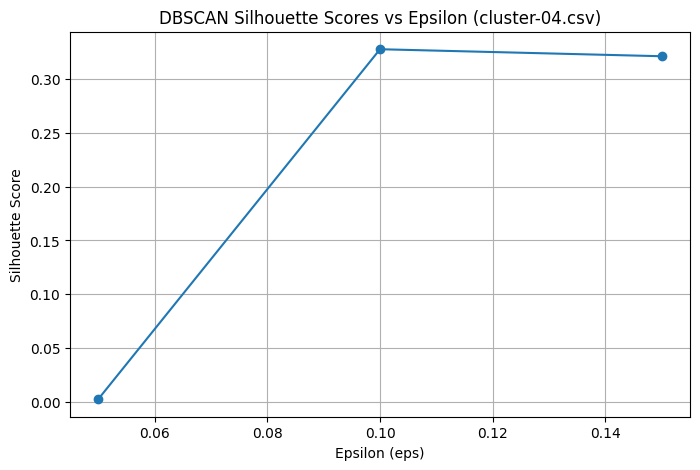

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results['eps'], results['silhouette_score'], marker='o')
plt.title("DBSCAN Silhouette Scores vs Epsilon (cluster-04.csv)")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

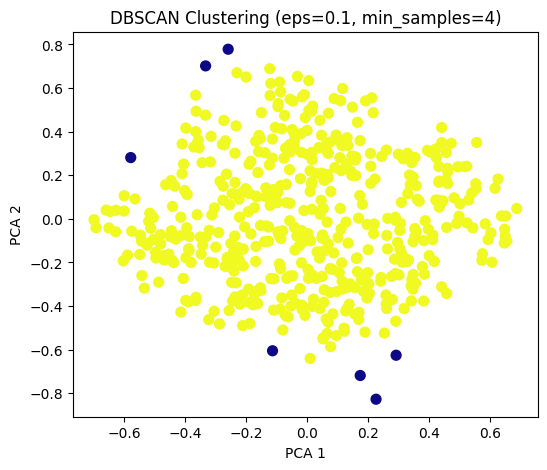

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels, cmap='plasma', s=50)
plt.title(f"DBSCAN Clustering (eps={best_eps}, min_samples={min_samples})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# **PART 2**

## **For Numbers 5 and 6**

In [ ]:
df3 = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-02.csv")
df3.head()

,V1,V2,V3,V4,V5
0,4.546780,19.484946,-0.976759,-1.399805,0.642537
1,4.028151,19.709271,-0.855106,-0.701296,0.787845
2,5.280579,20.175870,-0.215013,0.949428,0.550183
3,3.289170,18.632377,-0.040122,-0.095927,1.215803
4,5.336267,20.578907,0.200041,-0.496447,-1.575399


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df3)

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled)

In [ ]:
range_n = range(2, 8)  # try 2 to 7 clusters
silhouette_results = {"KMeans": [], "HC": [], "GMM": []}

In [ ]:
for k in range_n:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["KMeans"].append(score)

In [ ]:
for k in range_n:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["HC"].append(score)

In [ ]:
for k in range_n:
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["GMM"].append(score)

In [ ]:
results_df2 = pd.DataFrame(silhouette_results, index=range_n)
print("Silhouette Scores for Each Model:")
results_df2

Silhouette Scores for Each Model:


,KMeans,HC,GMM
2,0.352364,0.306324,0.351559
3,0.378893,0.324484,0.373734
4,0.366989,0.332227,0.358901
5,0.317080,0.291715,0.273717
6,0.358851,0.308627,0.350981
7,0.348130,0.297581,0.326807


# **5.**

In [ ]:
best_model = results_df2.max().idxmax()
best_k = results_df2[best_model].idxmax()
best_score = results_df2[best_model].max()

print("Best clustering model for dataset 'cluster-02.csv':", best_model)

Best clustering model for dataset 'cluster-02.csv': KMeans


# **6.**

In [ ]:
print("Best Silhouette Score:", round(best_score, 4))
print("Best Number of Clusters:", best_k)

Best Silhouette Score: 0.3789
Best Number of Clusters: 3


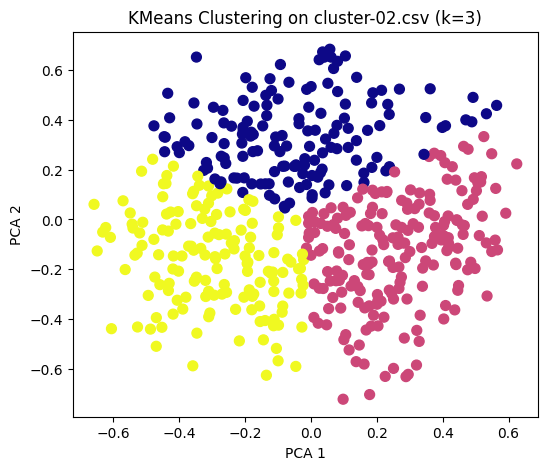

In [ ]:
kmeans_model_df3 = KMeans(n_clusters=3, random_state=42)
labels_df3 = kmeans_model_df3.fit_predict(pca_data)

plt.figure(figsize=(6, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_df3, cmap='plasma', s=50)
plt.title("KMeans Clustering on cluster-02.csv (k=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

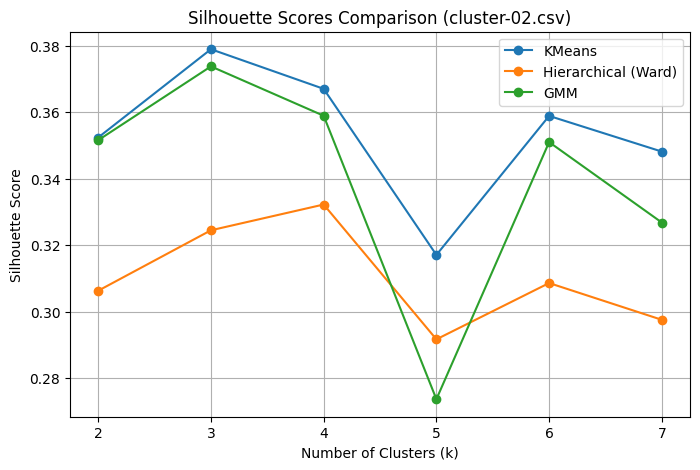

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results_df2.index, results_df2['KMeans'], marker='o', label='KMeans')
plt.plot(results_df2.index, results_df2['HC'], marker='o', label='Hierarchical (Ward)')
plt.plot(results_df2.index, results_df2['GMM'], marker='o', label='GMM')
plt.title("Silhouette Scores Comparison (cluster-02.csv)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()

# **For Numbers 7 to 8**

In [ ]:
df4 = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-05.csv")
df4.head()

,V1,V2,V4,V5,V6
0,-0.158353,-0.362053,-0.105631,-0.668469,0.439701
1,-0.049653,0.406525,-0.977228,0.399257,0.121315
2,0.403011,-0.099121,0.206530,-0.745633,-0.883326
3,-0.177414,-0.995773,-0.955961,0.392940,0.800324
4,0.664575,0.810209,-0.126706,0.952770,0.739398


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df4)

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled)

In [ ]:
min_samples = 2 * pca_data.shape[1]

In [ ]:
eps_values = np.arange(0.05, 1.01, 0.05)
sil_scores = []

for eps in eps_values:
    model = DBSCAN(eps=eps, min_samples=min_samples)
    labels = model.fit_predict(pca_data)

    # Silhouette only valid if at least 2 clusters
    if len(set(labels)) > 1 and -1 not in set(labels):
        score = silhouette_score(pca_data, labels)
        sil_scores.append(score)
    elif len(set(labels)) > 2:  # allow outliers if clusters exist
        score = silhouette_score(pca_data, labels)
        sil_scores.append(score)
    else:
        sil_scores.append(np.nan)

# **7.**

In [ ]:
results = pd.DataFrame({
    'eps': eps_values,
    'silhouette_score': sil_scores
})

best_eps = results.loc[results['silhouette_score'].idxmax(), 'eps']
best_score = results['silhouette_score'].max()

print("Best silhouette score:", round(best_score, 4))
print("Best epsilon value based on the best silhouette score:", round(best_eps, 2))

Best silhouette score: 0.2066
Best epsilon value based on the best silhouette score: 0.1


In [ ]:
dbscan = DBSCAN(eps=best_eps, min_samples=min_samples)
labels = dbscan.fit_predict(pca_data)

# **8.**

In [ ]:
outliers = np.sum(labels == -1)
print("Number of outliers detected:", outliers)

Number of outliers detected: 18


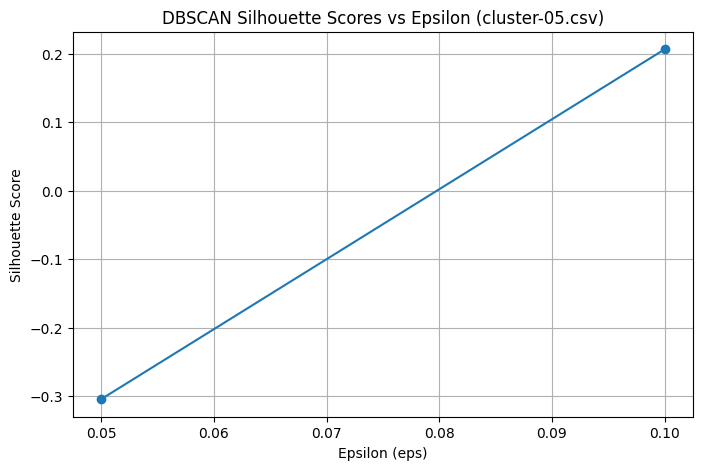

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results['eps'], results['silhouette_score'], marker='o')
plt.title("DBSCAN Silhouette Scores vs Epsilon (cluster-05.csv)")
plt.xlabel("Epsilon (eps)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

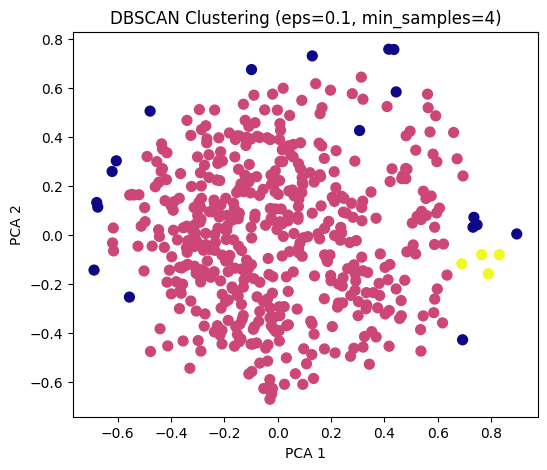

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels, cmap='plasma', s=50)
plt.title(f"DBSCAN Clustering (eps={best_eps}, min_samples={min_samples})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

# **PART 3**

In [ ]:
df5 = pd.read_csv('https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster-03.csv')
df5.head(5)


,V1,V2,V3,V4,V5
0,-8.536251,10.944791,6.811667,-5.059278,-3.186717
1,-11.222700,11.844886,5.491410,-5.308275,-4.855787
2,-10.917374,8.133306,6.445988,-5.033128,-8.411694
3,-13.920717,9.838101,7.073802,-6.943141,-5.553332
4,-4.238046,6.763134,4.887413,0.689276,-6.939081


In [ ]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df5)

In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(scaled)

In [ ]:
range_n = range(2, 8)  # test 2 to 7 clusters
silhouette_results = {"KMeans": [], "HC": [], "GMM": []}

In [ ]:
for k in range_n:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["KMeans"].append(score)

In [ ]:
for k in range_n:
    model = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["HC"].append(score)

In [ ]:
for k in range_n:
    model = GaussianMixture(n_components=k, random_state=42)
    labels = model.fit_predict(pca_data)
    score = silhouette_score(pca_data, labels)
    silhouette_results["GMM"].append(score)

In [ ]:
results_df3 = pd.DataFrame(silhouette_results, index=range_n)
print("Silhouette Scores for Each Model:\n")
results_df3

Silhouette Scores for Each Model:



,KMeans,HC,GMM
2,0.536087,0.536329,0.536087
3,0.651127,0.651127,0.648644
4,0.687359,0.686858,0.686858
5,0.635531,0.631560,0.635765
6,0.569565,0.556657,0.569183
7,0.537537,0.517498,0.534479


In [ ]:
best_model = results_df3.max().idxmax()
best_score = results_df3[best_model].max()
best_k = results_df3[best_model].idxmax()

# **9.**

In [ ]:
print("Best Model:", best_model)

Best Model: KMeans


# **10.**

In [ ]:
print("Best Silhouette Score:", round(best_score, 4))
print("Best Number of Clusters:", best_k)

Best Silhouette Score: 0.6874
Best Number of Clusters: 4


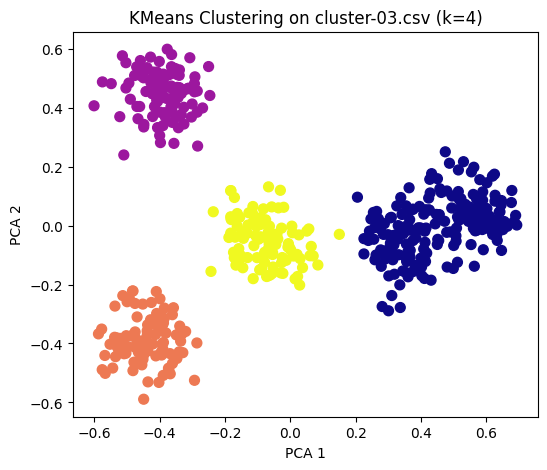

In [ ]:
kmeans_model_df5 = KMeans(n_clusters=4, random_state=42)
labels_df5 = kmeans_model_df5.fit_predict(pca_data)

plt.figure(figsize=(6, 5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels_df5, cmap='plasma', s=50)
plt.title("KMeans Clustering on cluster-03.csv (k=4)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

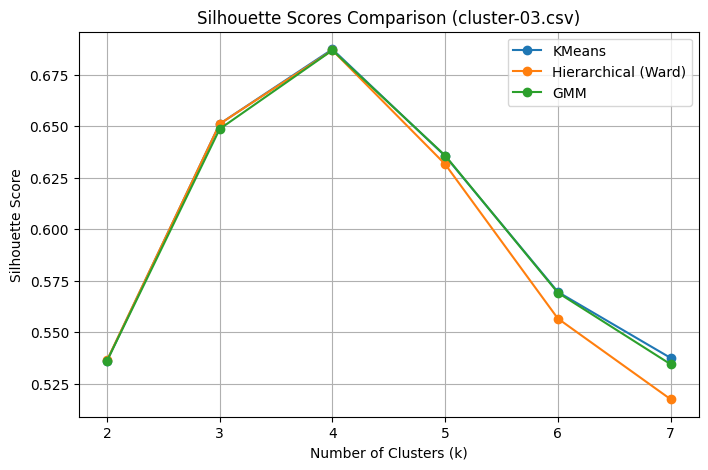

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(results_df3.index, results_df3['KMeans'], marker='o', label='KMeans')
plt.plot(results_df3.index, results_df3['HC'], marker='o', label='Hierarchical (Ward)')
plt.plot(results_df3.index, results_df3['GMM'], marker='o', label='GMM')
plt.title("Silhouette Scores Comparison (cluster-03.csv)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()